## Debugging of Vulkaneifel SMEW

In [1]:
from pathlib import Path
import importlib
import sys
import matplotlib.pyplot as plt
import seaborn as sns
base_path = r'/Users/estebangaitan/Documents/Github/SMEW'
repo_path = base_path
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)
repo_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "wrappers_postprocessing" / "zeroex_input_data_wrapper.py").is_file()
)
sys.path.insert(0, str(repo_root / "wrappers_postprocessing"))

import zeroex_input_data_wrapper as wp

--------------------------------------------------------------------------------------
Reading input files for Vulkaneifel ...
Input files read successfully.
--------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------
Running SMEW for Vulkaneifel ...


/Users/estebangaitan/Documents/Github/SMEW/smew/biogeochem.py:481: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  sol = fsolve(equations, x0, xtol=1e-12)


Weathered fraction in year  0 : [0.] idx: [0]
Weathered fraction in year  1 : [5.64937301] idx: [52560]
Weathered fraction in year  2 : [6.43071597] idx: [105120]
Weathered fraction in year  3 : [6.88666886] idx: [157680]
Weathered fraction in year  4 : [7.23118203] idx: [210240]
Weathered fraction in year  5 : [] idx: []
Model run finished.
--------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------
Plotting outputs for Vulkaneifel ...
Figures completed.
--------------------------------------------------------------------------------------


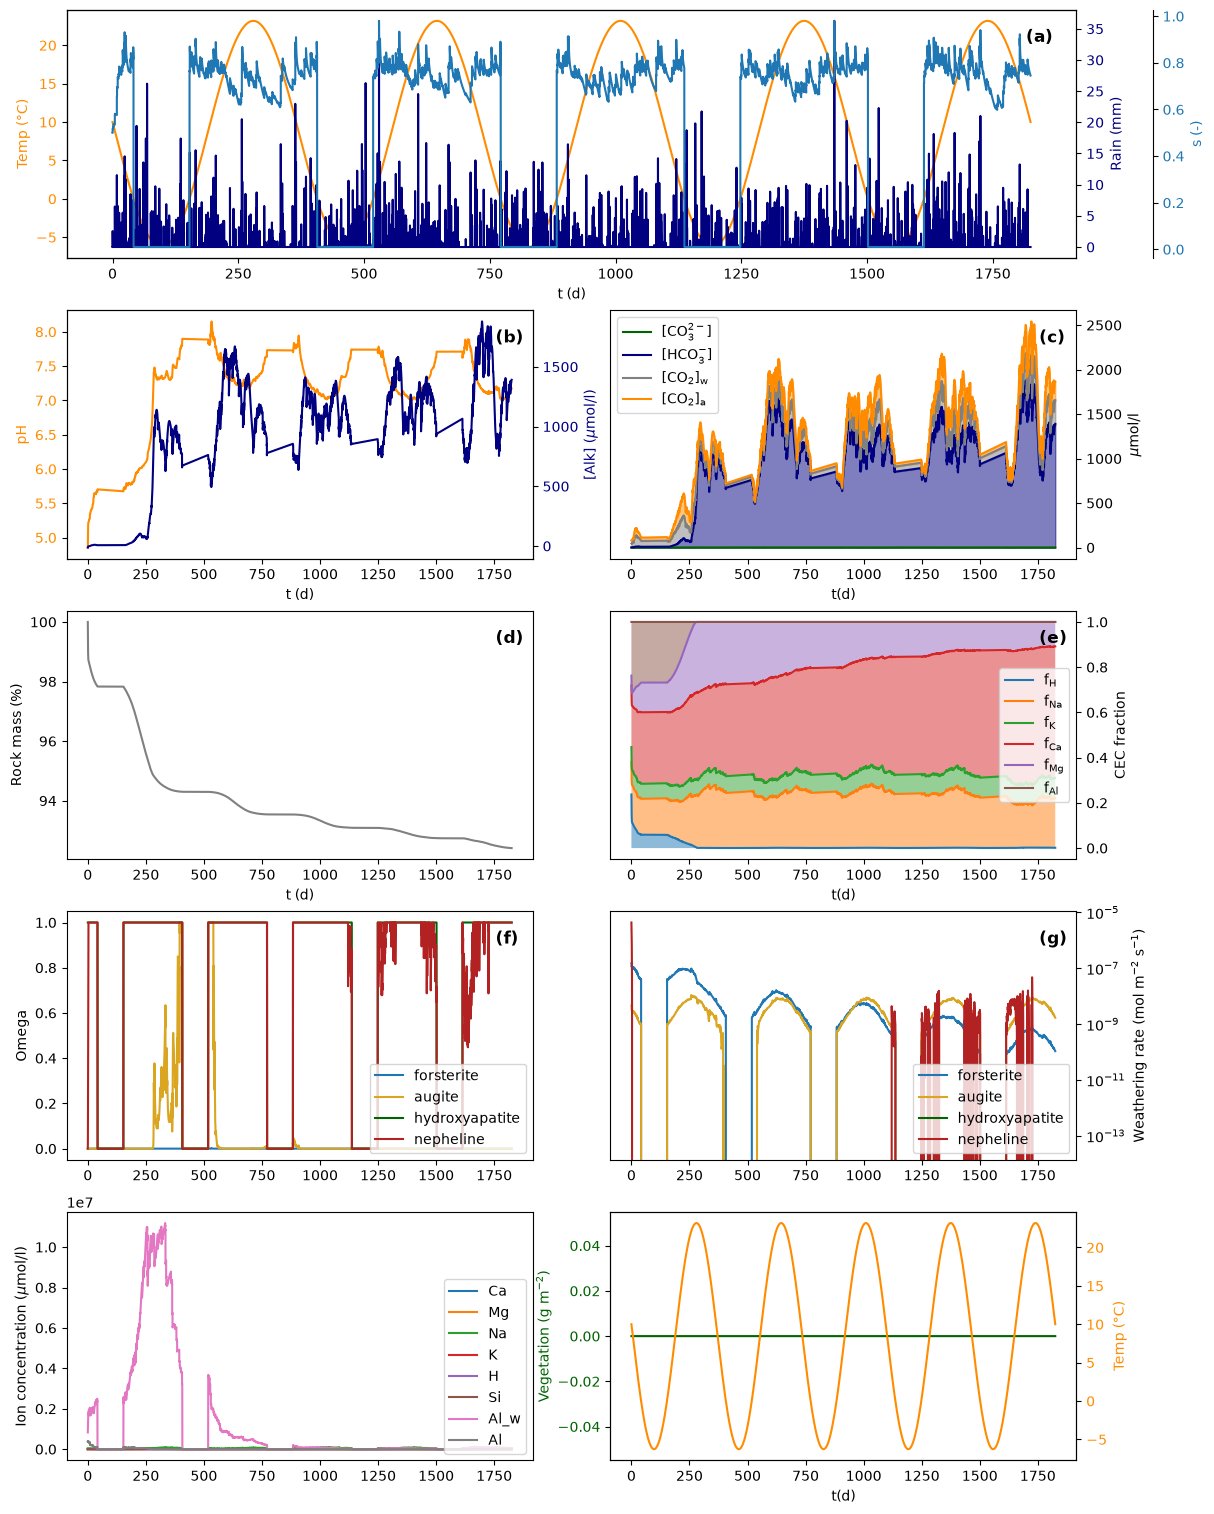

In [2]:
project = 'Vulkaneifel'
field_name = 'Field C'

input_data = wp.read_input_data(project_name=project,value_col=field_name)
output_data = wp.run_SMEW(project_name=project,input_data=input_data)
wp.create_plots(project_name=project,model_results=output_data)

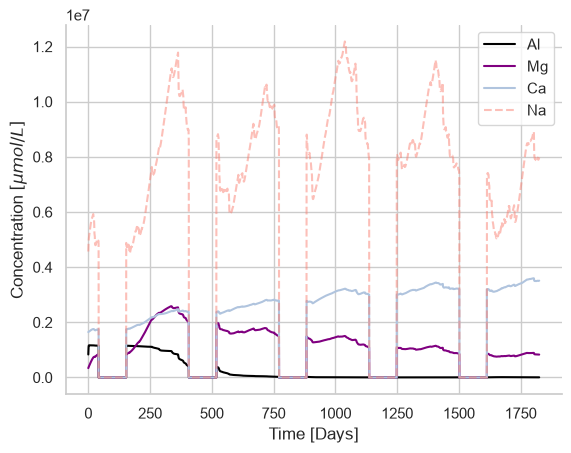

In [3]:
#Al tot corrected
Al_corr = output_data['Al_tot']/1000

sns.set_theme('notebook')
sns.set_style('whitegrid')


sns.lineplot(data=output_data,x='t',y=Al_corr,color='black',label='Al')
sns.lineplot(data=output_data,x='t',y='Mg_tot',color='purple',label='Mg')
sns.lineplot(data=output_data,x='t',y='Ca_tot',color='lightsteelblue',label='Ca')
sns.lineplot(data=output_data,x='t',y='Na_tot',color='salmon',linestyle='--',alpha=0.5,label='Na')
#sns.lineplot(data=output_data,x='t',y='H')

#formatting
plt.xlabel('Time [Days]')
plt.ylabel(r'Concentration $[\mu mol / L]$')
sns.despine()

## Conclusion

The Al-issue seems to be a **units issue**. The code in the case of Al uses both *conv_mol* and *conv_Al* – Check both `Example.ipynb` and `biochem.py`. Once the Al concentration is divided by 1000 to convert it to micromols $\mu$, the concentration shows values in the range of the other cations.

In [6]:
output_data.keys()

dict_keys(['pH', 'H', 'f_H', 'Alk', 'Alk_tot', 'An', 'An_tot', 'CO2_w', 'CO2_air', 'HCO3', 'CO3', 'DIC', 'IC_tot', 'Fs', 'ADV', 'DIC_rain', 'Ca', 'Ca_tot', 'f_Ca', 'UP_Ca', 'Mg', 'Mg_tot', 'f_Mg', 'UP_Mg', 'K', 'K_tot', 'f_K', 'Na', 'Na_tot', 'f_Na', 'Si', 'Si_tot', 'UP_Si', 'Al', 'AlOH', 'AlOH2', 'AlOH3', 'AlOH4', 'Al_w', 'Al_tot', 'f_Al', 'M_rock', 'CaCO3', 'MgCO3', 'W_CaCO3', 'W_MgCO3', 'EW', 'Wr', 'Omega', 'M_min', 's', 'temp_soil', 'v', 'I', 'L', 'T', 'Dw', 'r_het', 'r_aut', 'min_st', 'xi', 'I_Ca', 'I_Mg', 'I_K', 'I_Na', 'I_Si', 'I_An', 'n', 'Zr', 'dt', 'conv_mol', 'conv_Al', 'k_v', 'RAI', 'root_d', 'mineral', 'clip_Ca', 'clip_Mg', 'clip_K', 'clip_Na', 'clip_Al', 'clip_Si', 'clip_An', 'clip_C', 'clip_CaCO3', 'clip_MgCO3', 'clip_M_min', 'dt_max', 'n_substeps', 't', 'rain', 's_filtered'])

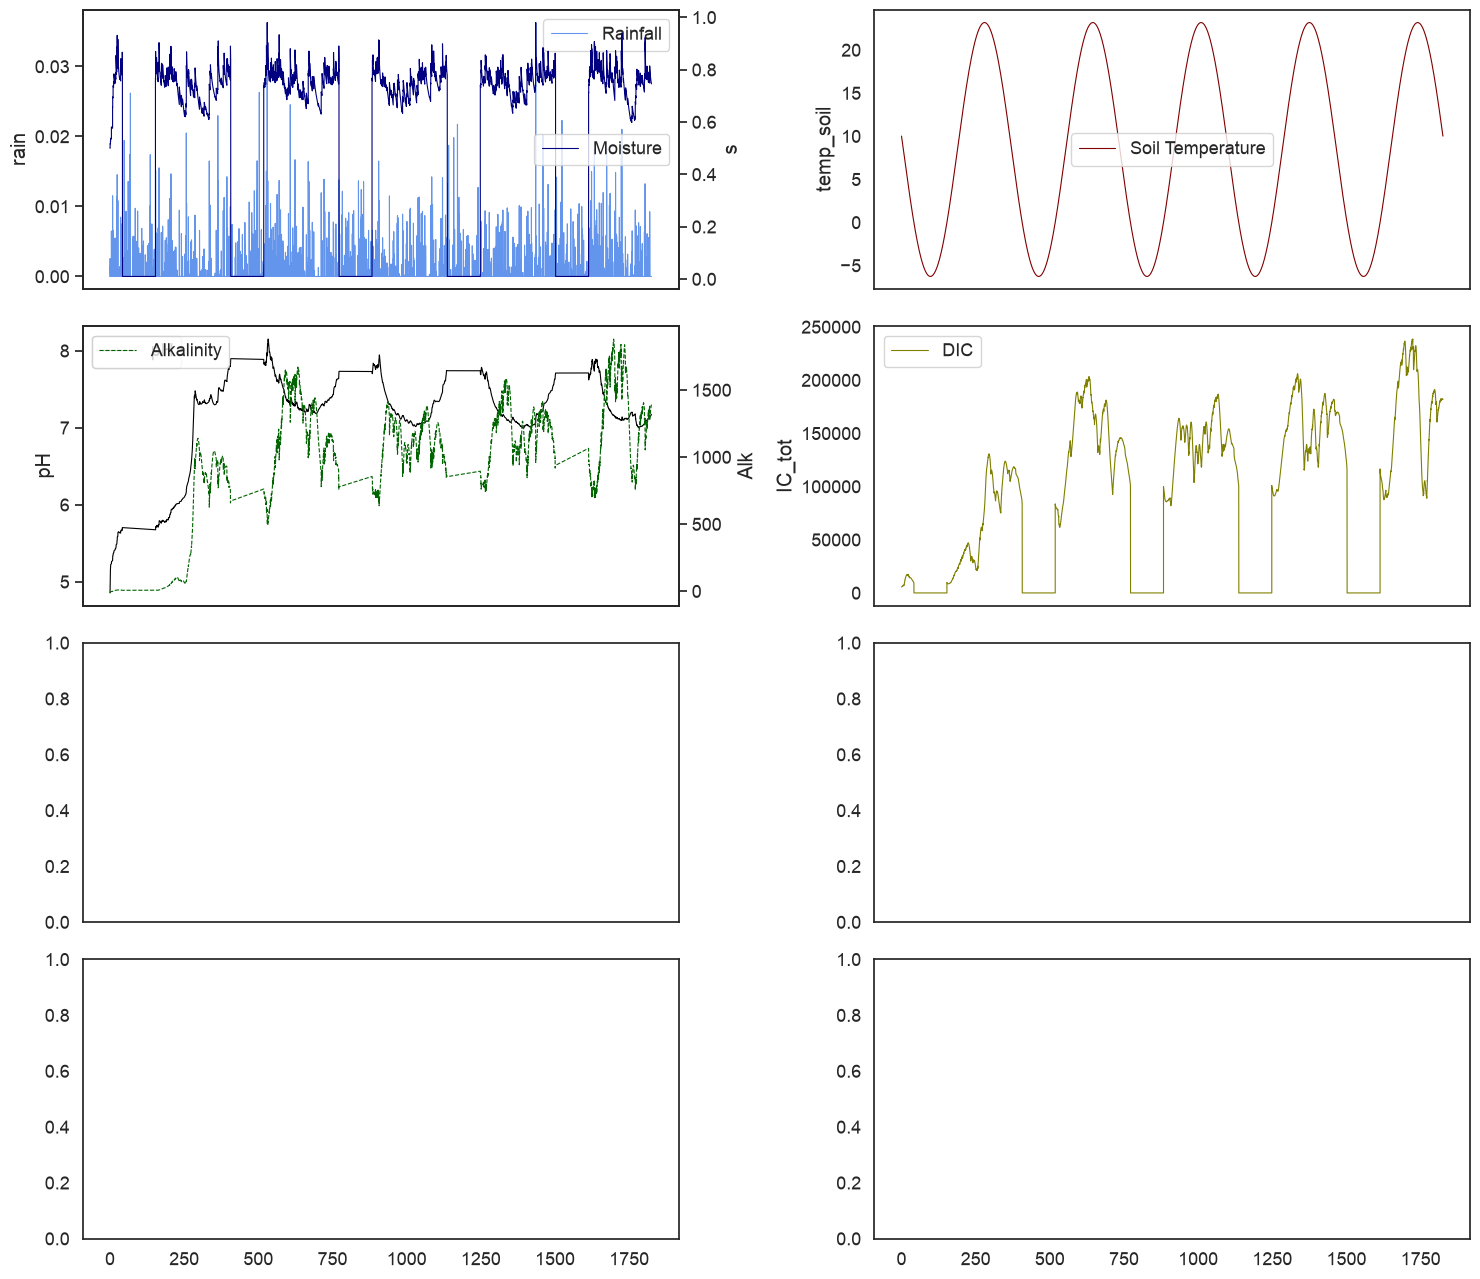

In [34]:
sns.set_theme('notebook',font_scale=1.2)
sns.set_style('white')
fig, ax = plt.subplots(4,2,figsize=(15, 13),sharex=True,sharey=False)

#Climate panel
ax_s = ax[0,0].twinx()
sns.lineplot(data=output_data,x='t',y='rain',color='cornflowerblue',label='Rainfall',ax=ax[0,0],linewidth=0.8)
sns.lineplot(data=output_data,x='t',y='s',color='navy',label='Moisture',ax=ax_s,linewidth=0.8)
sns.lineplot(data=output_data,x='t',y='temp_soil',color='maroon',label='Soil Temperature',ax=ax[0,1],linewidth=0.8)


#pH panel and alkalinity
ax_alk = ax[1,0].twinx()
sns.lineplot(data=output_data,x='t',y='pH',color='black',label='pH',ax=ax[1,0],linewidth=0.8)
sns.lineplot(data=output_data,x='t',y='Alk',color='darkgreen',label='Alkalinity',ax=ax_alk,linewidth=0.8,linestyle='--')

#DIC
#sns.lineplot(data=output_data,x='t',y='DIC',color='olive',label='DIC',ax=ax[1,1],linewidth=0.8)
sns.lineplot(data=output_data,x='t',y='IC_tot',color='olive',label='DIC',ax=ax[1,1],linewidth=0.8)
fig.tight_layout(pad=1.0)